# Warm evaluation split (leave-last-out)

This notebook creates a **robust split to evaluate personalized recommenders** (CF / ALS / item-item):

- Builds `user_item_interactions` (user_id, item_id, ts) from the raw Olist CSVs (only `delivered`).
- Filters **users with ≥ 2 interactions**.
- Applies **leave-last-out** per user:
  - `warm_test_ll`: last interaction per user (1 event per user)
  - `warm_train_ll`: the remaining interactions (history)

The splits are exported to `data/processed/warm/` in Parquet format.


# Imports and Paths

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
OUT_DIR = PROJECT_ROOT / "data" / "processed" / "warm"
OUT_DIR.mkdir(parents=True, exist_ok=True)

ORDERS_PATH = RAW_DIR / "olist_orders_dataset.csv"
ITEMS_PATH = RAW_DIR / "olist_order_items_dataset.csv"
CUSTOMERS_PATH = RAW_DIR / "olist_customers_dataset.csv"

print("RAW_DIR:", RAW_DIR)
print("OUT_DIR:", OUT_DIR)


RAW_DIR: c:\Users\Jesus\Documents\olist_nlp\data\raw
OUT_DIR: c:\Users\Jesus\Documents\olist_nlp\data\processed\warm


# Load Data

In [10]:
# raw
orders_df = pd.read_csv(ORDERS_PATH)
items_df = pd.read_csv(ITEMS_PATH)
customers_df = pd.read_csv(CUSTOMERS_PATH)

orders_df["order_purchase_timestamp"] = pd.to_datetime(
    orders_df["order_purchase_timestamp"], errors="coerce"
)

print("orders:", orders_df.shape)
print("items:", items_df.shape)
print("customers:", customers_df.shape)


orders: (99441, 8)
items: (112650, 7)
customers: (99441, 5)


In [11]:
# Build user-item interactions (KEEP order_id)
orders_delivered = orders_df[orders_df["order_status"] == "delivered"].copy()

orders_enriched = orders_delivered.merge(
    customers_df[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="inner",
)

user_item_interactions = (
    orders_enriched[["order_id", "customer_unique_id", "order_purchase_timestamp"]]
    .merge(items_df[["order_id", "product_id"]], on="order_id", how="inner")
    .rename(
        columns={
            "customer_unique_id": "user_id",
            "product_id": "item_id",
            "order_purchase_timestamp": "ts",
        }
    )
)

# Keep minimum fields + deduplicate
user_item_interactions = (
    user_item_interactions[["user_id", "order_id", "item_id", "ts"]]
    .drop_duplicates(["user_id", "order_id", "item_id"])  # order_id already pins ts
    .dropna(subset=["user_id", "order_id", "item_id", "ts"])
    .copy()
)

# Deterministic ordering (helps with tie-breaking)
user_item_interactions = user_item_interactions.sort_values(
    ["user_id", "ts", "order_id", "item_id"]
).reset_index(drop=True)

print("user_item_interactions:", user_item_interactions.shape)
print("unique users:", user_item_interactions["user_id"].nunique())
print("unique items:", user_item_interactions["item_id"].nunique())
print("unique orders:", user_item_interactions["order_id"].nunique())
print(
    "min/max ts:",
    user_item_interactions["ts"].min(),
    user_item_interactions["ts"].max(),
)

user_item_interactions.head()

user_item_interactions: (100196, 4)
unique users: 93358
unique items: 32216
unique orders: 96478
min/max ts: 2016-09-15 12:16:38 2018-08-29 15:00:37


,user_id,order_id,item_id,ts
0,0000366f3b9a7992bf8c76cfdf3221e2,e22acc9c116caa3f2b7121bbb380d08e,372645c7439f9661fbbacfd129aa92ec,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3594e05a005ac4d06a72673270ef9ec9,5099f7000472b634fea8304448d20825,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,b33ec3b699337181488304f362a6b734,64b488de448a5324c4134ea39c28a34b,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,41272756ecddd9a9ed0180413cc22fb6,2345a354a6f2033609bbf62bf5be9ef6,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,d957021f1127559cd947b62533f484f7,c72e18b3fe2739b8d24ebf3102450f37,2017-11-14 19:45:42


## Recurrence diagnostics (orders per user + events per user)


--- Recurrence diagnostics ---
Total users: 93358
% users with 1 order   : 97.00%
% users with ≥2 orders : 3.00%
% users with ≥3 orders : 0.24%


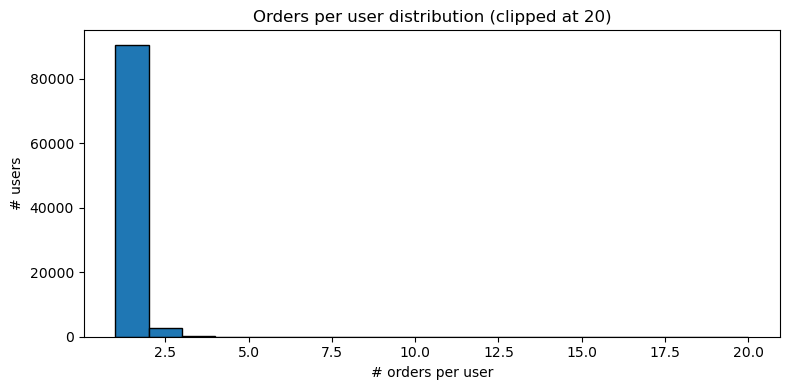

In [12]:
events_per_user = user_item_interactions.groupby("user_id").size()
orders_per_user = user_item_interactions.groupby("user_id")["order_id"].nunique()

print("\n--- Recurrence diagnostics ---")
print("Total users:", orders_per_user.shape[0])
print(f"% users with 1 order   : {(orders_per_user == 1).mean() * 100:.2f}%")
print(f"% users with ≥2 orders : {(orders_per_user >= 2).mean() * 100:.2f}%")
print(f"% users with ≥3 orders : {(orders_per_user >= 3).mean() * 100:.2f}%")

plt.figure(figsize=(8, 4))
bins = [1, 2, 3, 4, 5, 10, 20]
plt.hist(orders_per_user.clip(upper=20), bins=bins, edgecolor="black")
plt.title("Orders per user distribution (clipped at 20)")
plt.xlabel("# orders per user")
plt.ylabel("# users")
plt.tight_layout()
plt.show()

## Warm subset: users with >=2 ORDERS (needed for order-level holdout)

In [17]:
warm_users = orders_per_user[orders_per_user >= 2].index
df_warm = user_item_interactions[
    user_item_interactions["user_id"].isin(warm_users)
].copy()

print("\n--- Warm subset (>=2 orders) ---")
print("df_warm rows :", df_warm.shape[0])
print("warm users   :", df_warm["user_id"].nunique())
print("avg events/user:", df_warm.shape[0] / df_warm["user_id"].nunique())
print("avg orders/user:", df_warm.groupby("user_id")["order_id"].nunique().mean())


--- Warm subset (>=2 orders) ---
df_warm rows : 6352
warm users   : 2801
avg events/user: 2.267761513745091
avg orders/user: 2.1138878971795787


# Leave-last-out BY ORDER
Hold out the last order per user (all its items go to test)

In [14]:
user_orders = (
    df_warm[["user_id", "order_id", "ts"]]
    .drop_duplicates(["user_id", "order_id"])
    .sort_values(["user_id", "ts", "order_id"])  # deterministic tie-break
)

last_orders = user_orders.groupby("user_id").tail(1)[["user_id", "order_id"]].copy()

warm_test_ll = df_warm.merge(last_orders, on=["user_id", "order_id"], how="inner")

warm_train_ll = df_warm.merge(
    last_orders, on=["user_id", "order_id"], how="left", indicator=True
)
warm_train_ll = warm_train_ll[warm_train_ll["_merge"] == "left_only"].drop(
    columns=["_merge"]
)

print("\n--- WARM LEAVE-LAST-OUT (ORDER-LEVEL) ---")
print(
    "warm_train_ll:",
    warm_train_ll.shape,
    "| users:",
    warm_train_ll["user_id"].nunique(),
    "| orders:",
    warm_train_ll["order_id"].nunique(),
)
print(
    "warm_test_ll :",
    warm_test_ll.shape,
    "| users:",
    warm_test_ll["user_id"].nunique(),
    "| orders:",
    warm_test_ll["order_id"].nunique(),
)


--- WARM LEAVE-LAST-OUT (ORDER-LEVEL) ---
warm_train_ll: (3350, 4) | users: 2801 | orders: 3120
warm_test_ll : (3002, 4) | users: 2801 | orders: 2801


# Sanity checks

In [15]:
# Sanity checks

# A) Same users in train and test
train_users = set(warm_train_ll["user_id"].unique())
test_users = set(warm_test_ll["user_id"].unique())
print("Users in test not in train:", len(test_users - train_users))

# B) Exactly 1 TEST ORDER per user
test_orders_per_user = warm_test_ll.groupby("user_id")["order_id"].nunique()
print(
    "min/max test orders per user:",
    int(test_orders_per_user.min()),
    int(test_orders_per_user.max()),
)

# C) No overlap in (user_id, order_id) between train and test
train_pairs = set(zip(warm_train_ll["user_id"], warm_train_ll["order_id"]))
test_pairs = set(zip(warm_test_ll["user_id"], warm_test_ll["order_id"]))
print("Overlapping (user, order) pairs:", len(train_pairs & test_pairs))

# D) Timestamp ordering: last order ts should be >= any train order ts per user
train_max_ts = warm_train_ll.groupby("user_id")["ts"].max()
test_ts = warm_test_ll.groupby("user_id")["ts"].max()
viol = (train_max_ts > test_ts).mean() * 100
print(f"% violations (max train ts > test ts): {viol:.6f}%")

# E) Item cold-start inside warm (optional but recommended)
train_items = set(warm_train_ll["item_id"].unique())
test_items = set(warm_test_ll["item_id"].unique())
print("Test items unseen in warm_train_ll:", len(test_items - train_items))

Users in test not in train: 0
min/max test orders per user: 1 1
Overlapping (user, order) pairs: 0
% violations (max train ts > test ts): 0.000000%
Test items unseen in warm_train_ll: 1765


## Export models

In [16]:
warm_train_ll.to_parquet(OUT_DIR / "warm_train_loo_orders.parquet", index=False)
warm_test_ll.to_parquet(OUT_DIR / "warm_test_loo_orders.parquet", index=False)
pd.Series(sorted(list(test_users)), name="user_id").to_csv(
    OUT_DIR / "warm_users.csv", index=False
)

print("\nExported:")
print("-", OUT_DIR / "warm_train_loo_orders.parquet")
print("-", OUT_DIR / "warm_test_loo_orders.parquet")
print("-", OUT_DIR / "warm_users.csv")


Exported:
- c:\Users\Jesus\Documents\olist_nlp\data\processed\warm\warm_train_loo_orders.parquet
- c:\Users\Jesus\Documents\olist_nlp\data\processed\warm\warm_test_loo_orders.parquet
- c:\Users\Jesus\Documents\olist_nlp\data\processed\warm\warm_users.csv
